In [1]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()
gc.collect()

print("Memory cleared.")

2026-05-14 20:06:51.043179: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Memory cleared.


In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

In [3]:
PROJECT_ROOT = "/home/jovyan"

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 5e-6

KEEP_CLASSES = ["akiec", "bcc", "bkl", "mel", "nv"]
NUM_CLASSES = len(KEEP_CLASSES)

print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("MODELS_DIR:", MODELS_DIR)

DATA_DIR: /home/jovyan/data
RESULTS_DIR: /home/jovyan/results
MODELS_DIR: /home/jovyan/models


In [4]:
metadata_path = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
df = pd.read_csv(metadata_path)

image_dirs = [
    os.path.join(DATA_DIR, "HAM10000_images_part_1"),
    os.path.join(DATA_DIR, "HAM10000_images_part_2")
]

image_path_dict = {}

for image_dir in image_dirs:
    for filename in os.listdir(image_dir):
        if filename.endswith(".jpg"):
            image_id = filename.replace(".jpg", "")
            image_path_dict[image_id] = os.path.join(image_dir, filename)

df["image_path"] = df["image_id"].map(image_path_dict)

print("Total rows before filtering:", len(df))
print("Missing image paths:", df["image_path"].isna().sum())

df = df.dropna(subset=["image_path"]).copy()

Total rows before filtering: 10015
Missing image paths: 0


In [5]:
df_5 = df[df["dx"].isin(KEEP_CLASSES)].copy()

print("Rows after filtering:", len(df_5))
print("\nClass distribution:")
print(df_5["dx"].value_counts())

Rows after filtering: 9758

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
Name: count, dtype: int64


In [6]:
class_to_label = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "mel": 3,
    "nv": 4
}

label_to_class = {
    0: "akiec",
    1: "bcc",
    2: "bkl",
    3: "mel",
    4: "nv"
}

df_5["label"] = df_5["dx"].map(class_to_label)

print(df_5[["image_id", "dx", "label", "image_path"]].head())
print("\nLabel distribution:")
print(df_5["label"].value_counts().sort_index())

       image_id   dx  label                                         image_path
0  ISIC_0027419  bkl      2  /home/jovyan/data/HAM10000_images_part_1/ISIC_...
1  ISIC_0025030  bkl      2  /home/jovyan/data/HAM10000_images_part_1/ISIC_...
2  ISIC_0026769  bkl      2  /home/jovyan/data/HAM10000_images_part_1/ISIC_...
3  ISIC_0025661  bkl      2  /home/jovyan/data/HAM10000_images_part_1/ISIC_...
4  ISIC_0031633  bkl      2  /home/jovyan/data/HAM10000_images_part_2/ISIC_...

Label distribution:
label
0     327
1     514
2    1099
3    1113
4    6705
Name: count, dtype: int64


In [7]:
train_df = pd.read_csv(os.path.join(RESULTS_DIR, "train_split_5class.csv"))
val_df = pd.read_csv(os.path.join(RESULTS_DIR, "val_split_5class.csv"))
test_df = pd.read_csv(os.path.join(RESULTS_DIR, "test_split_5class.csv"))

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["dx"].value_counts())

print("\nValidation distribution:")
print(val_df["dx"].value_counts())

print("\nTest distribution:")
print(test_df["dx"].value_counts())

Train: 7025
Validation: 781
Test: 1952

Train distribution:
dx
nv       4827
mel       801
bkl       791
bcc       370
akiec     236
Name: count, dtype: int64

Validation distribution:
dx
nv       537
mel       89
bkl       88
bcc       41
akiec     26
Name: count, dtype: int64

Test distribution:
dx
nv       1341
mel       223
bkl       220
bcc       103
akiec      65
Name: count, dtype: int64


In [8]:
classes = np.sort(train_df["label"].unique())

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    int(c): min(float(w), 2.0)
    for c, w in zip(classes, class_weights_array)

}

print("Capped class weights:")
for k, v in class_weights.items():
    print(f"{label_to_class[k]} ({k}): {v:.4f}")

Capped class weights:
akiec (0): 2.0000
bcc (1): 2.0000
bkl (2): 1.7762
mel (3): 1.7541
nv (4): 0.2911


In [9]:
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_df["label"].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values, val_df["label"].values)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_df["label"].values)
)

train_ds = (
    train_ds
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

I0000 00:00:1778789238.089326   91278 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13294 MB memory:  -> device: 0, name: NVIDIA A16, pci bus id: 0000:46:00.0, compute capability: 8.6


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


2026-05-14 20:07:19.936113: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,147,333 (92.11 MB)

 Trainable params: 15,009,029 (57.25 MB)

 Non-trainable params: 9,138,304 (34.86 MB)

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, "resnet50_5class_best.keras"),
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

model.save(os.path.join(MODELS_DIR, "resnet50_5class_run1.keras"))
print("5-class ResNet model saved.")

Epoch 1/15


2026-05-14 20:07:42.753452: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


220/220 ━━━━━━━━━━━━━━━━━━━━ 97s 336ms/step - accuracy: 0.3653 - loss: 1.4226 - val_accuracy: 0.0653 - val_loss: 1.8611
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 70s 310ms/step - accuracy: 0.4091 - loss: 1.2659 - val_accuracy: 0.1344 - val_loss: 2.3695
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 72s 318ms/step - accuracy: 0.4218 - loss: 1.2464 - val_accuracy: 0.6069 - val_loss: 1.1277
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 70s 312ms/step - accuracy: 0.4491 - loss: 1.1798 - val_accuracy: 0.5864 - val_loss: 1.2318
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 70s 309ms/step - accuracy: 0.4604 - loss: 1.1703 - val_accuracy: 0.2804 - val_loss: 2.2435
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 71s 316ms/step - accuracy: 0.4541 - loss: 1.1622 - val_accuracy: 0.5211 - val_loss: 1.4520
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 71s 314ms/step - accuracy: 0.4688 - loss: 1.1206 - val_accuracy: 0.4699 - val_loss: 1.4449
Epoch 8/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 69s 306ms/step - accuracy: 0.4648 - loss: 1.1371 - val

In [12]:
best_model = tf.keras.models.load_model(
    os.path.join(MODELS_DIR, "resnet50_5class_best.keras")
)

y_true = test_df["label"].values

y_prob = best_model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

labels = [label_to_class[i] for i in range(NUM_CLASSES)]

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("Confusion matrix:")
display(cm_df)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

61/61 ━━━━━━━━━━━━━━━━━━━━ 12s 166ms/step
Confusion matrix:


,akiec,bcc,bkl,mel,nv
akiec,0,31,22,3,9
bcc,1,48,27,1,26
bkl,1,43,104,8,64
mel,0,38,96,35,54
nv,2,131,173,29,1006



Classification report:
              precision    recall  f1-score   support

       akiec     0.0000    0.0000    0.0000        65
         bcc     0.1649    0.4660    0.2437       103
         bkl     0.2464    0.4727    0.3240       220
         mel     0.4605    0.1570    0.2341       223
          nv     0.8680    0.7502    0.8048      1341

    accuracy                         0.6112      1952
   macro avg     0.3480    0.3692    0.3213      1952
weighted avg     0.6854    0.6112    0.6290      1952



In [ ]:
metrics = []

for i, class_name in label_to_class.items():
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    metrics.append({
        "Class": class_name,
        "Sensitivity/Recall": sensitivity,
        "Specificity": specificity,
        "Support": np.sum(cm[i, :])
    })

metrics_df = pd.DataFrame(metrics)

balanced_accuracy = metrics_df["Sensitivity/Recall"].mean()

display(metrics_df)

print("Balanced accuracy:", round(balanced_accuracy, 4))

In [ ]:
mel_metrics = metrics_df[metrics_df["Class"] == "mel"]
display(mel_metrics)

In [ ]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

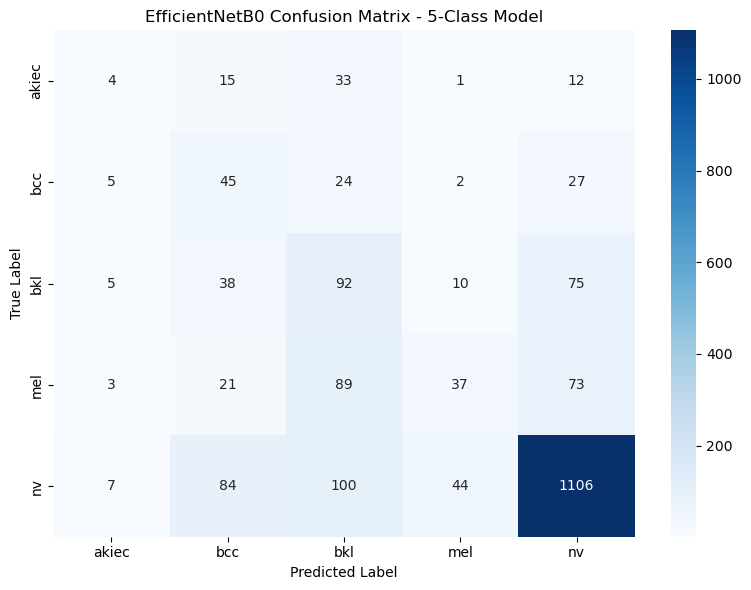

Saved to: /home/jovyan/results/efficientnet_5class_confusion_matrix.png


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

class_names = ["akiec", "bcc", "bkl", "mel", "nv"]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Confusion Matrix - 5-Class Model")

plt.tight_layout()

save_path = os.path.join(RESULTS_DIR, "resnet50_5class_confusion_matrix.png")
plt.savefig(save_path, dpi=300)

plt.show()

print("Saved to:", save_path)